In [2]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct


In [2]:
# Chargement du signal audio et conversion en mono
y, Fs = librosa.load("SON.wav", sr=None, mono=True)


print("Fs =", Fs)
print("Signal x[n] de longueur :",len(y))

Fs = 44100
Signal x[n] de longueur : 412672


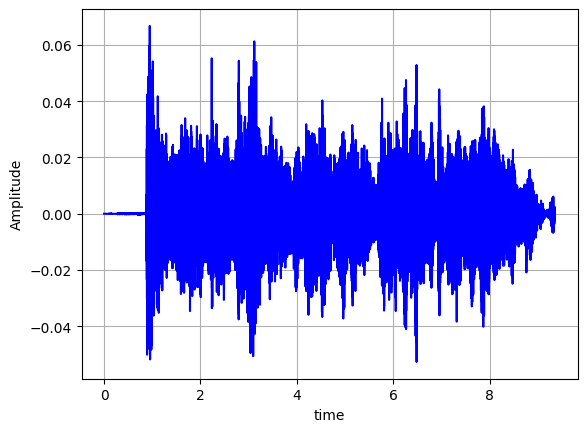

In [ ]:
#Visualisation du signal audio

x=[i*(1/Fs) for i in range(412672)]

plt.plot(x, y, label="Son",color='blue')
plt.xlabel('time')
plt.ylabel('Amplitude')
plt.grid()

In [3]:
#Découpage du signal en trames
frame_length =int(0.025 * Fs)
hop_length   =int(0.010 * Fs)

frames = librosa.util.frame(
    y,
    frame_length=frame_length,
    hop_length=hop_length
).T

print(frames.shape)# (nombre_frames, frame_length)
print(frames[40])

(934, 1102)
[-9.1552734e-05 -7.6293945e-05 -6.1035156e-05 ... -6.1035156e-05
 -9.1552734e-05 -6.1035156e-05]


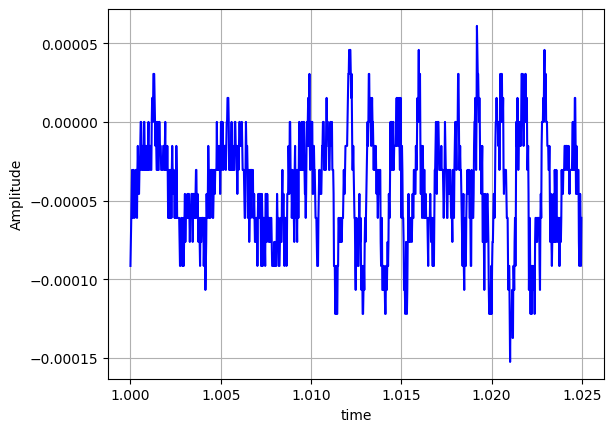

In [11]:
#Visualisation de la première trame

frame1_time = [i*(1/Fs) for i in range(44100,44100+1102)]
frame1 = frames[40]  # Première trame
plt.plot(frame1_time, frame1, label="Son frame 1",color='blue')
plt.xlabel('time')
plt.ylabel('Amplitude')
plt.grid()

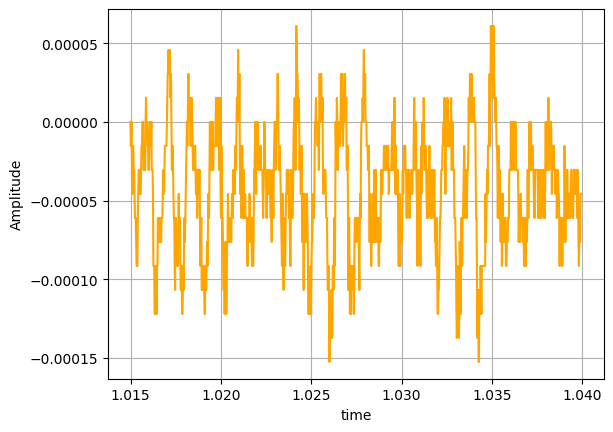

In [ ]:
#Visualisation de la deuxième trame

frame2_time = [i*(1/Fs) for i in range(44761, 44761+1102)]
frame2 = frames[41]  # Deuxième trame
plt.plot(frame2_time, frame2, label="Son frame 2",color='orange')
plt.xlabel('time')
plt.ylabel('Amplitude')
plt.grid()

(1762,)


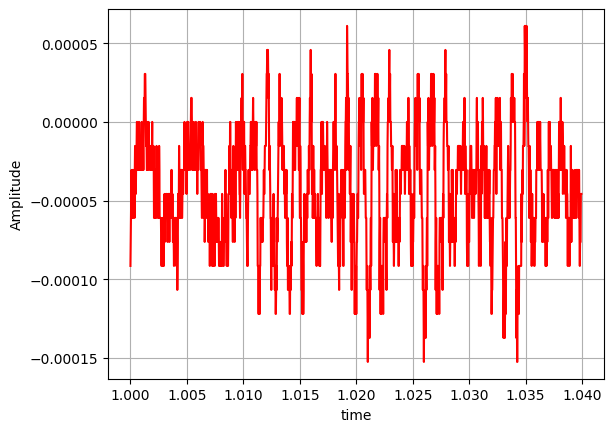

In [ ]:

#Visualisation de la troisième trame (frame0 + frame1)
frame3 = []
#print(frames[40][0])
for i in range(1102):
    frame3.append(frames[40][i])

for i in range(442,1102):
    frame3.append(frames[41][i])

frame3 = np.array(frame3)


frame3_time = [i * (1/Fs) for i in range(44100, 44761+1101)]
#print(frame3_time)
print(frame3.shape)


plt.plot(frame3_time, frame3, label="Son frame 1 + 2",color='red')
plt.xlabel('time')
plt.ylabel('Amplitude')
plt.grid()




In [4]:
# Fenêtrage de chaque trame
window = np.hamming(frame_length)

windowed_frames = frames * window

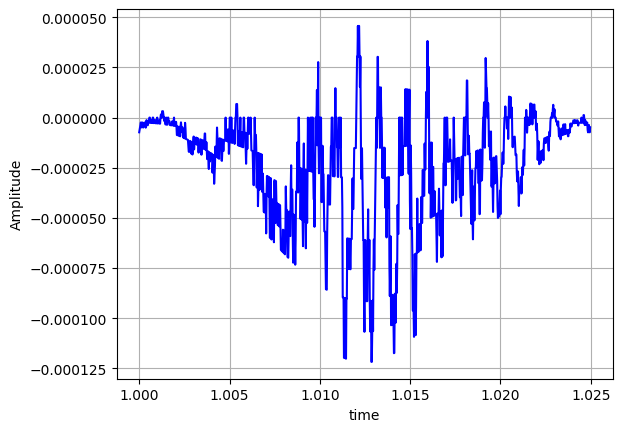

In [ ]:
#Visualisation de la première trame fenêtrée

frame1_time = [i*(1/Fs) for i in range(44100,44100+1102)]
frame1 = windowed_frames[40]  # Première trame
plt.plot(frame1_time, frame1, label="Son frame 1",color='blue')
plt.xlabel('time')
plt.ylabel('Amplitude')
plt.grid()

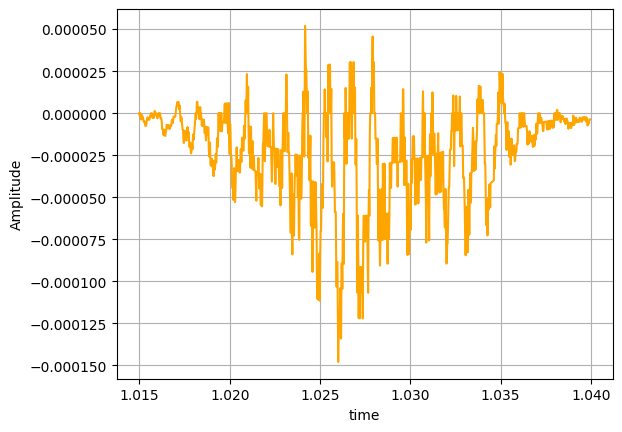

In [ ]:
#Visualisation de la deuxième trame fenêtrée

frame2_time = [i*(1/Fs) for i in range(44761, 44761+1102)]
frame2 = windowed_frames[41]  # Deuxième trame
plt.plot(frame2_time, frame2, label="Son frame 2",color='orange')
plt.xlabel('time')
plt.ylabel('Amplitude')
plt.grid()

(1762,)


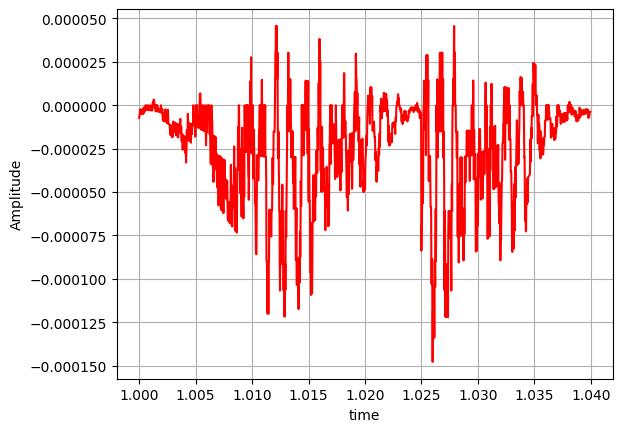

In [ ]:
#Visualisation de la troisième trame fenêtrée (frame0 + frame1)
frame3 = []
#print(frames[40][0])
for i in range(1102):
    frame3.append(windowed_frames[40][i])

for i in range(442,1102):
    frame3.append(windowed_frames[41][i])

frame3 = np.array(frame3)


frame3_time = [i * (1/Fs) for i in range(44100, 44761+1101)]
#print(frame3_time)
print(frame3.shape)


plt.plot(frame3_time, frame3, label="Son frame 1 + 2",color='red')
plt.xlabel('time')
plt.ylabel('Amplitude')
plt.grid()




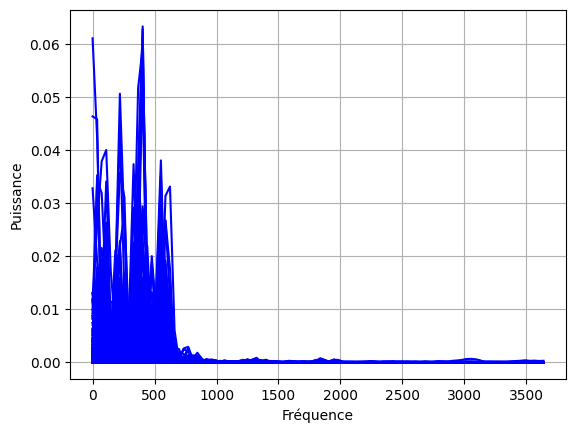

In [9]:
# FFT de chaque trame
NFFT=1200  

fft_frames = np.fft.rfft(windowed_frames, n=NFFT)
magnitude = np.abs(fft_frames) # calcul de l'amplitude de chaque composante fréquentielle
power_spectrum = (magnitude **2) / NFFT


#Spectre fréquentiel frame par frame 
g=[i*Fs/NFFT for i in range(100)]
for i in range(934):
    plt.plot(g, power_spectrum[i,:100], label=f"Spectre fréquentiel Frame {i}",color='blue')
plt.xlabel('Fréquence')
plt.ylabel('Puissance')
plt.grid()

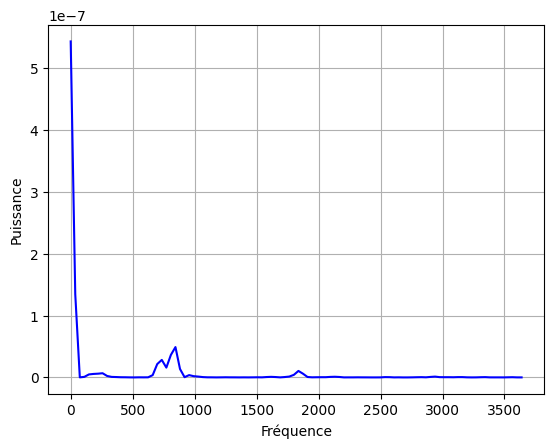

In [10]:
#Spectre fréquentiel frame 40
plt.plot(g, power_spectrum[40,:100], label=f"Spectre fréquentiel Frame {i}",color='blue')
plt.xlabel('Fréquence')
plt.ylabel('Puissance')
plt.grid()

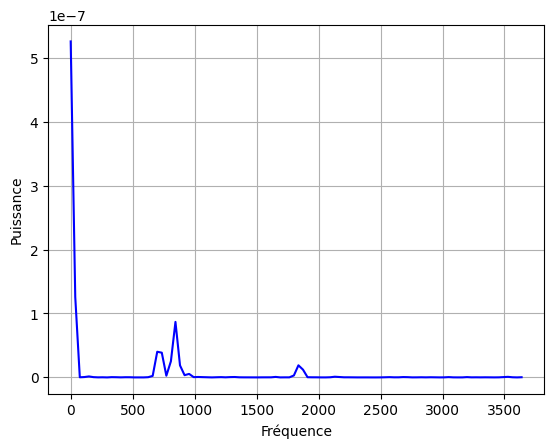

In [11]:
#Spectre fréquentiel frame 41
plt.plot(g, power_spectrum[41,:100], label=f"Spectre fréquentiel Frame {i}",color='blue')
plt.xlabel('Fréquence')
plt.ylabel('Puissance')
plt.grid()

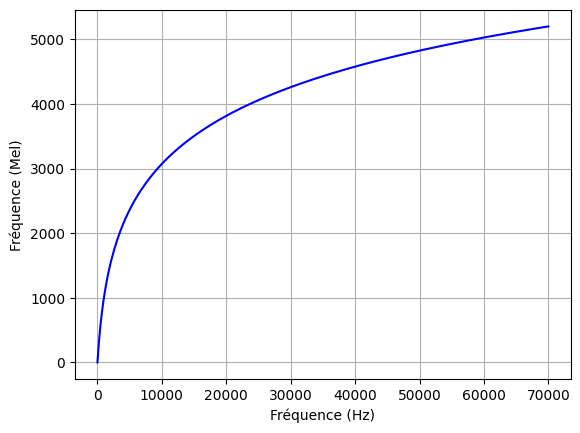

In [5]:
#Tracé de la courbe de Mel
def hz_to_mel(hz):
    return 2595 * np.log10(1 + hz / 700)

hz_values = np.linspace(0, 70000, 300)
mel_values = hz_to_mel(hz_values)

plt.plot(hz_values, mel_values, label="Courbe de Mel",color='blue')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Fréquence (Mel)')
plt.grid()

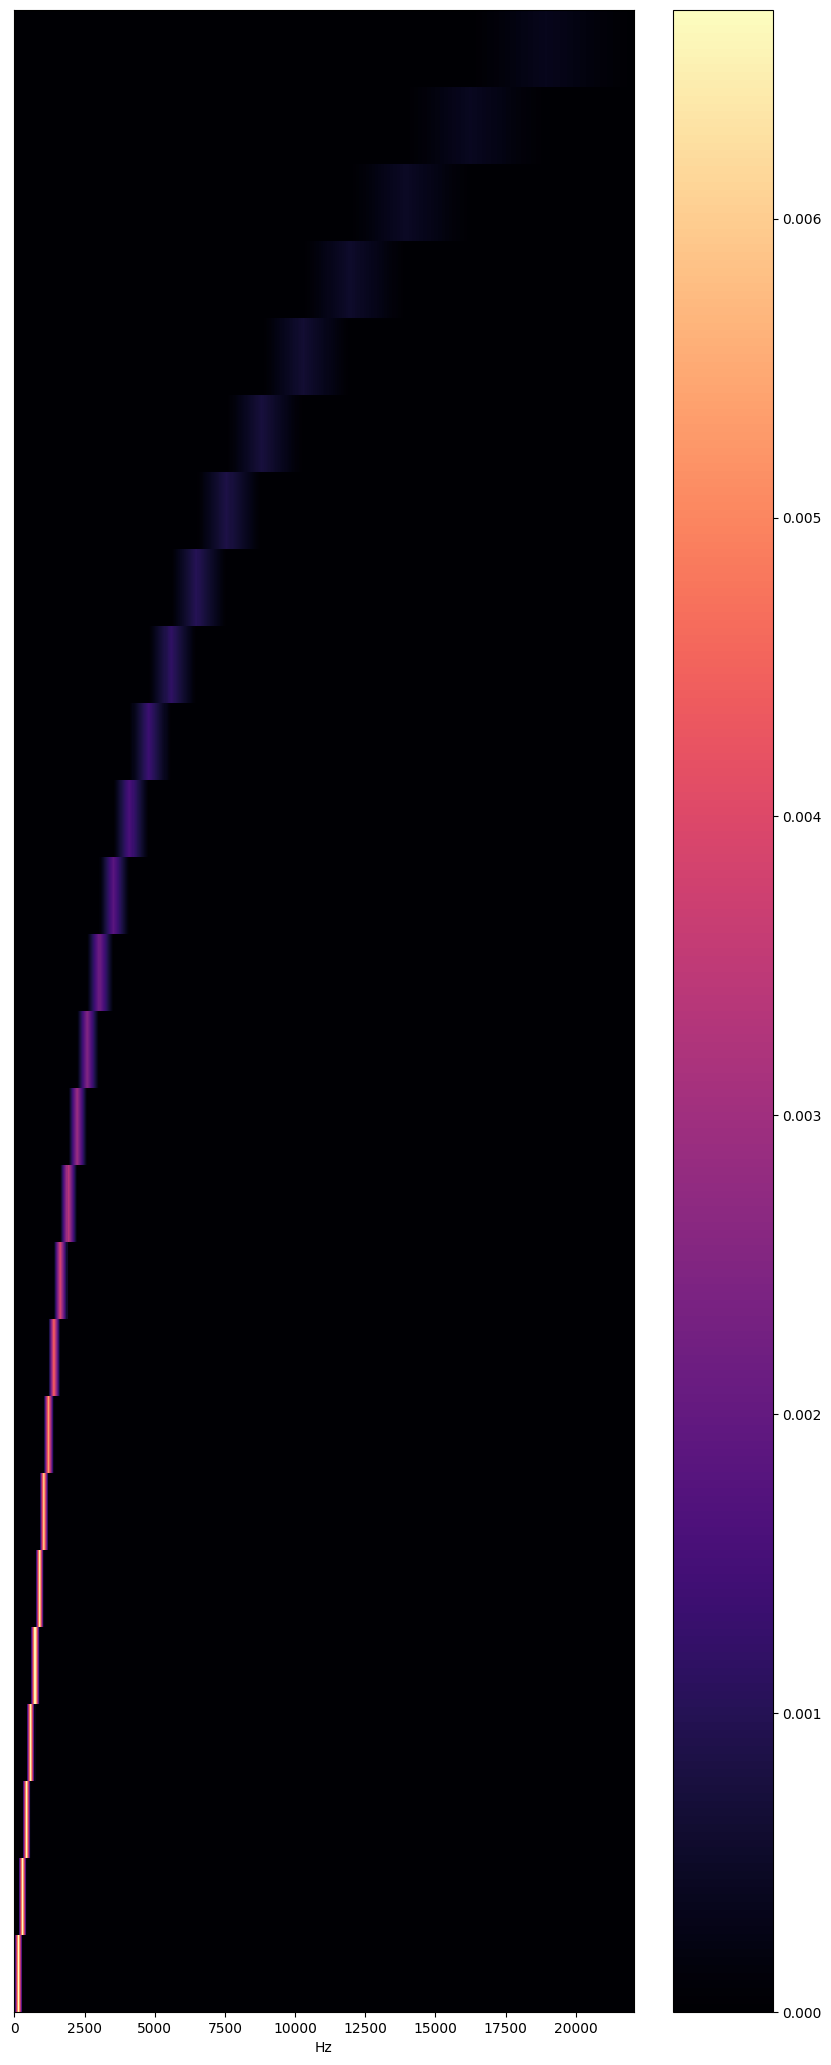

In [7]:
# Bank de filtres de Mel
import librosa.display
n_mels =26

mel_filters = librosa.filters.mel(
    sr=Fs,
    n_fft=NFFT,
    n_mels=n_mels,
    fmax=Fs/2
)

plt.figure(figsize=(10,26))
librosa.display.specshow( mel_filters,
                         sr=Fs,
                         x_axis="linear")

plt.colorbar()
plt.show()

(934, 26)


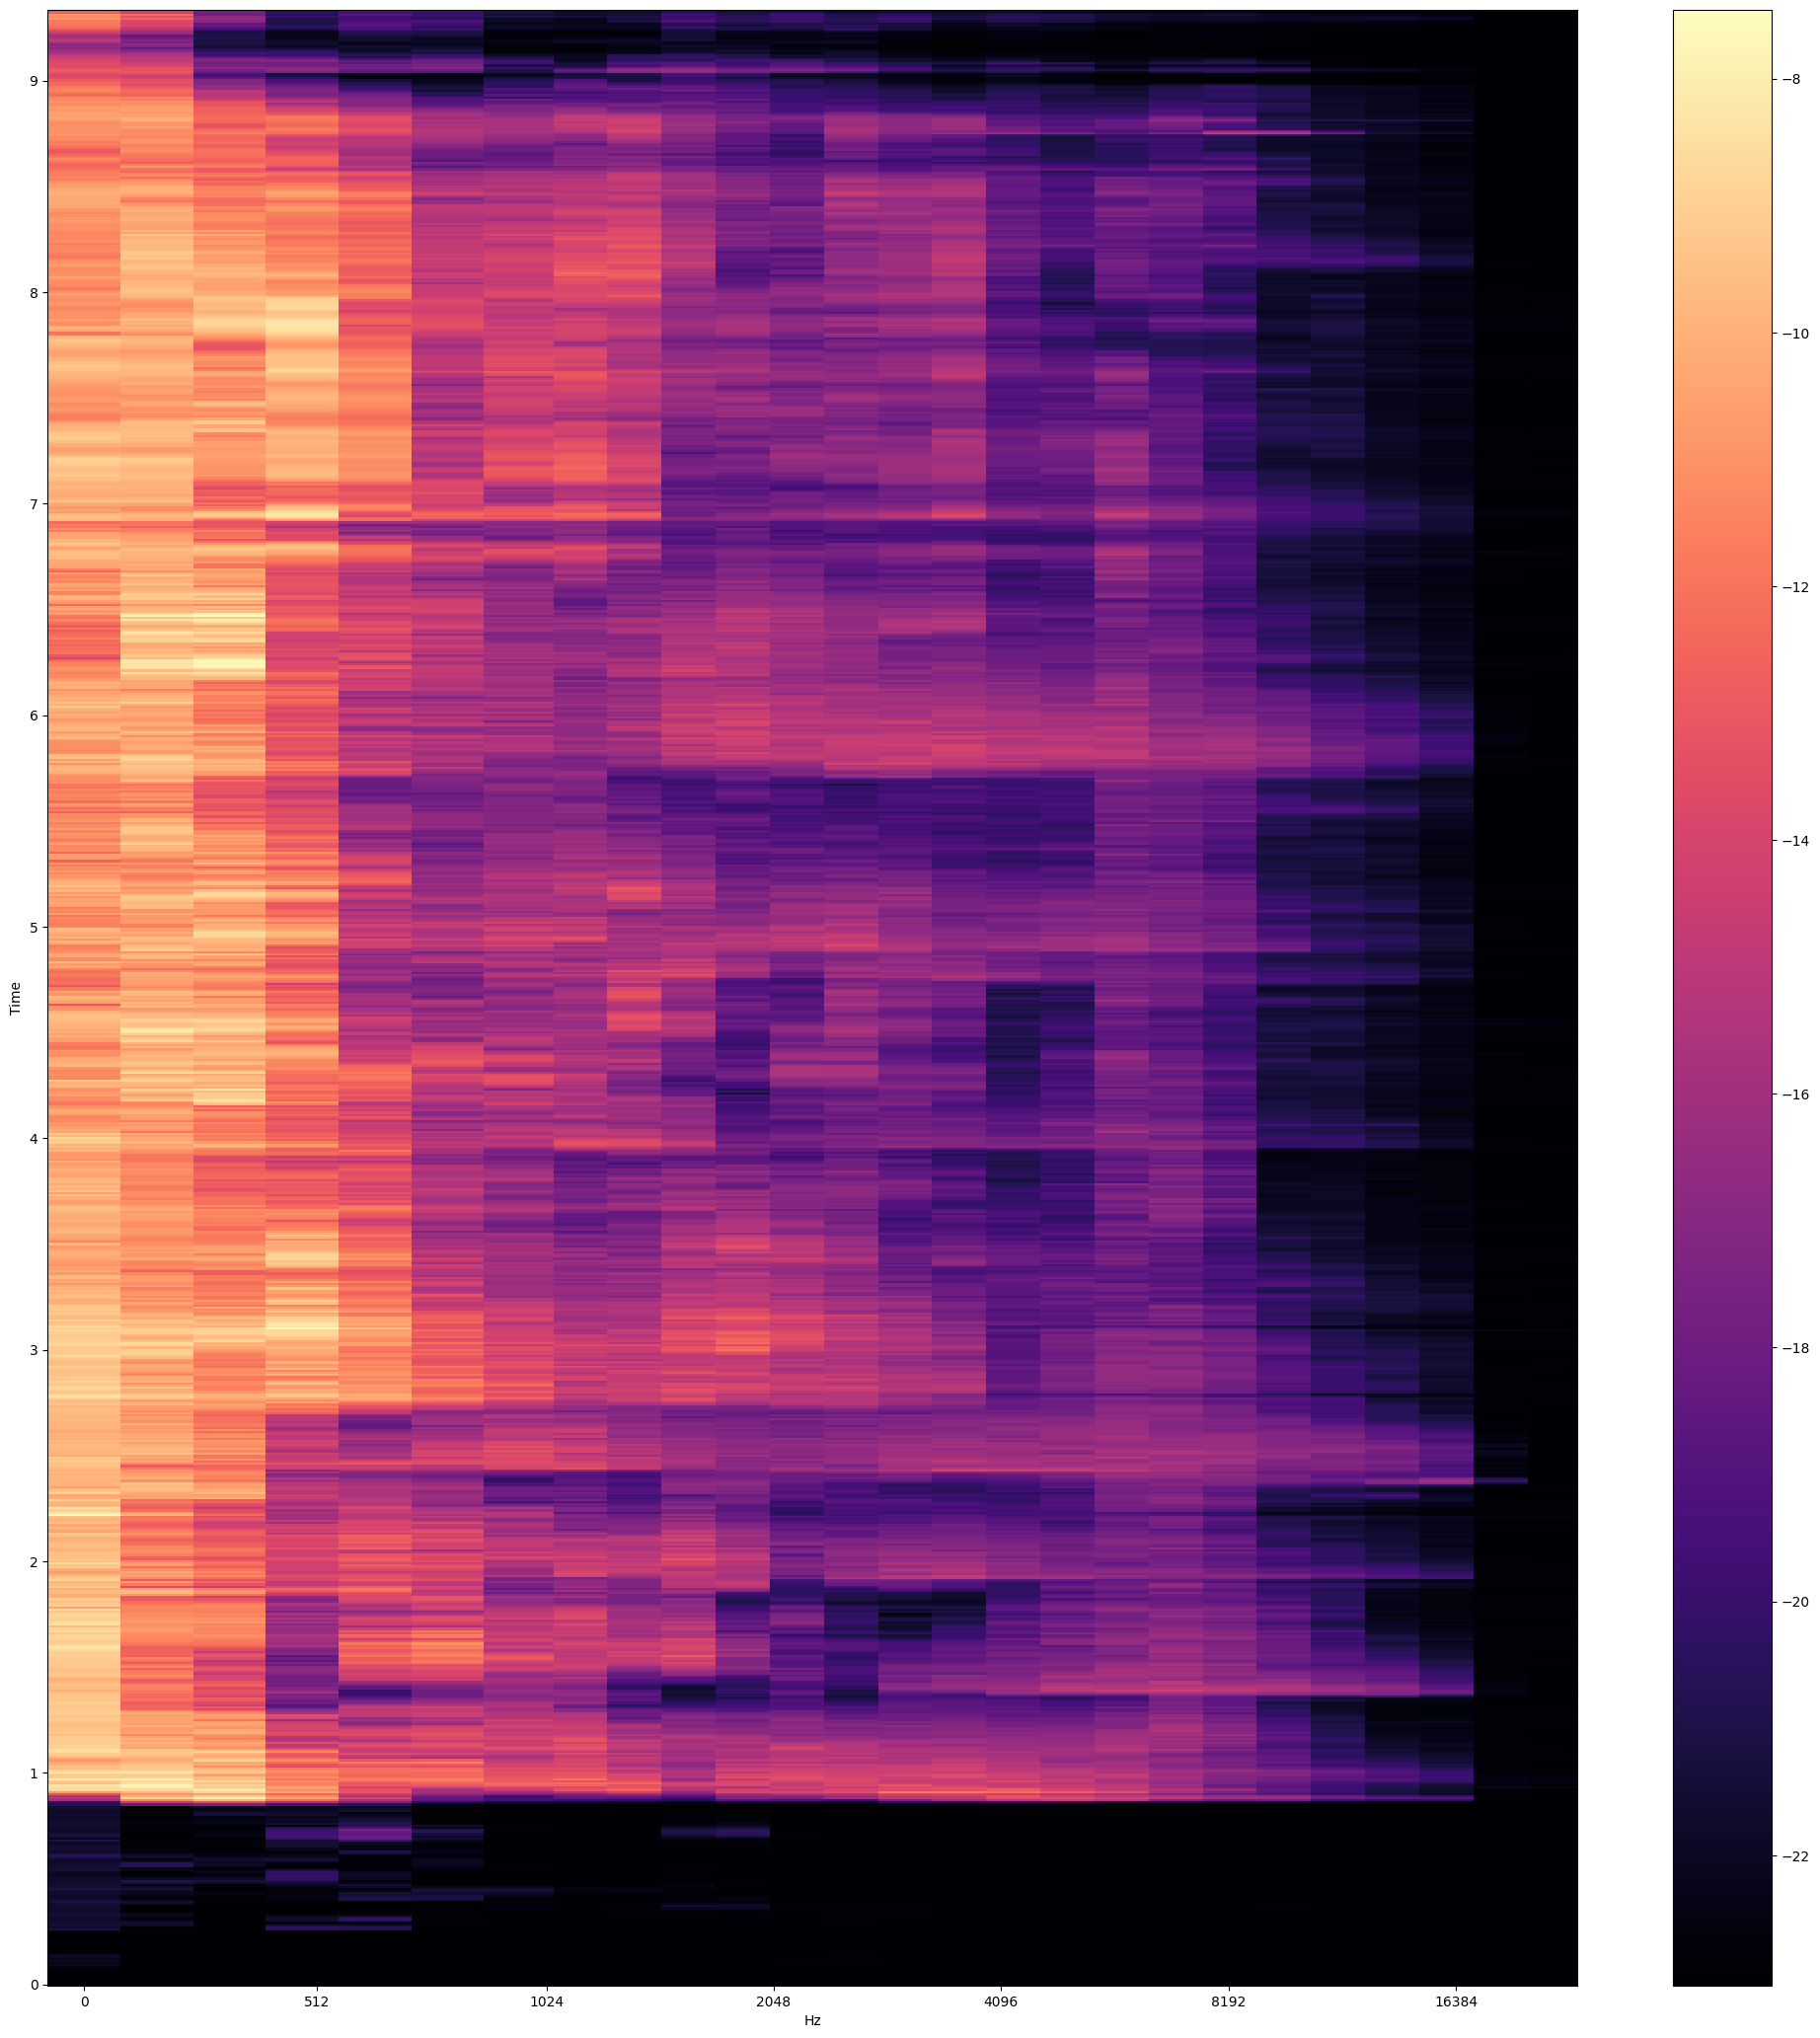

In [ ]:
#Spectrogramme de Mel
mel_spectrum = np.dot(power_spectrum, mel_filters.T)
# Log du spectrogramme de Mel
log_mel_spectrum = np.log(mel_spectrum +1e-10) # 1e-10 : pour éviter les problèmes de log(0)
print(log_mel_spectrum.shape)
plt.figure(figsize=(25,26))
librosa.display.specshow( log_mel_spectrum,
                         sr=Fs,
                         x_axis="mel",
                         y_axis="time",
                         hop_length=441)

plt.colorbar()
plt.show()


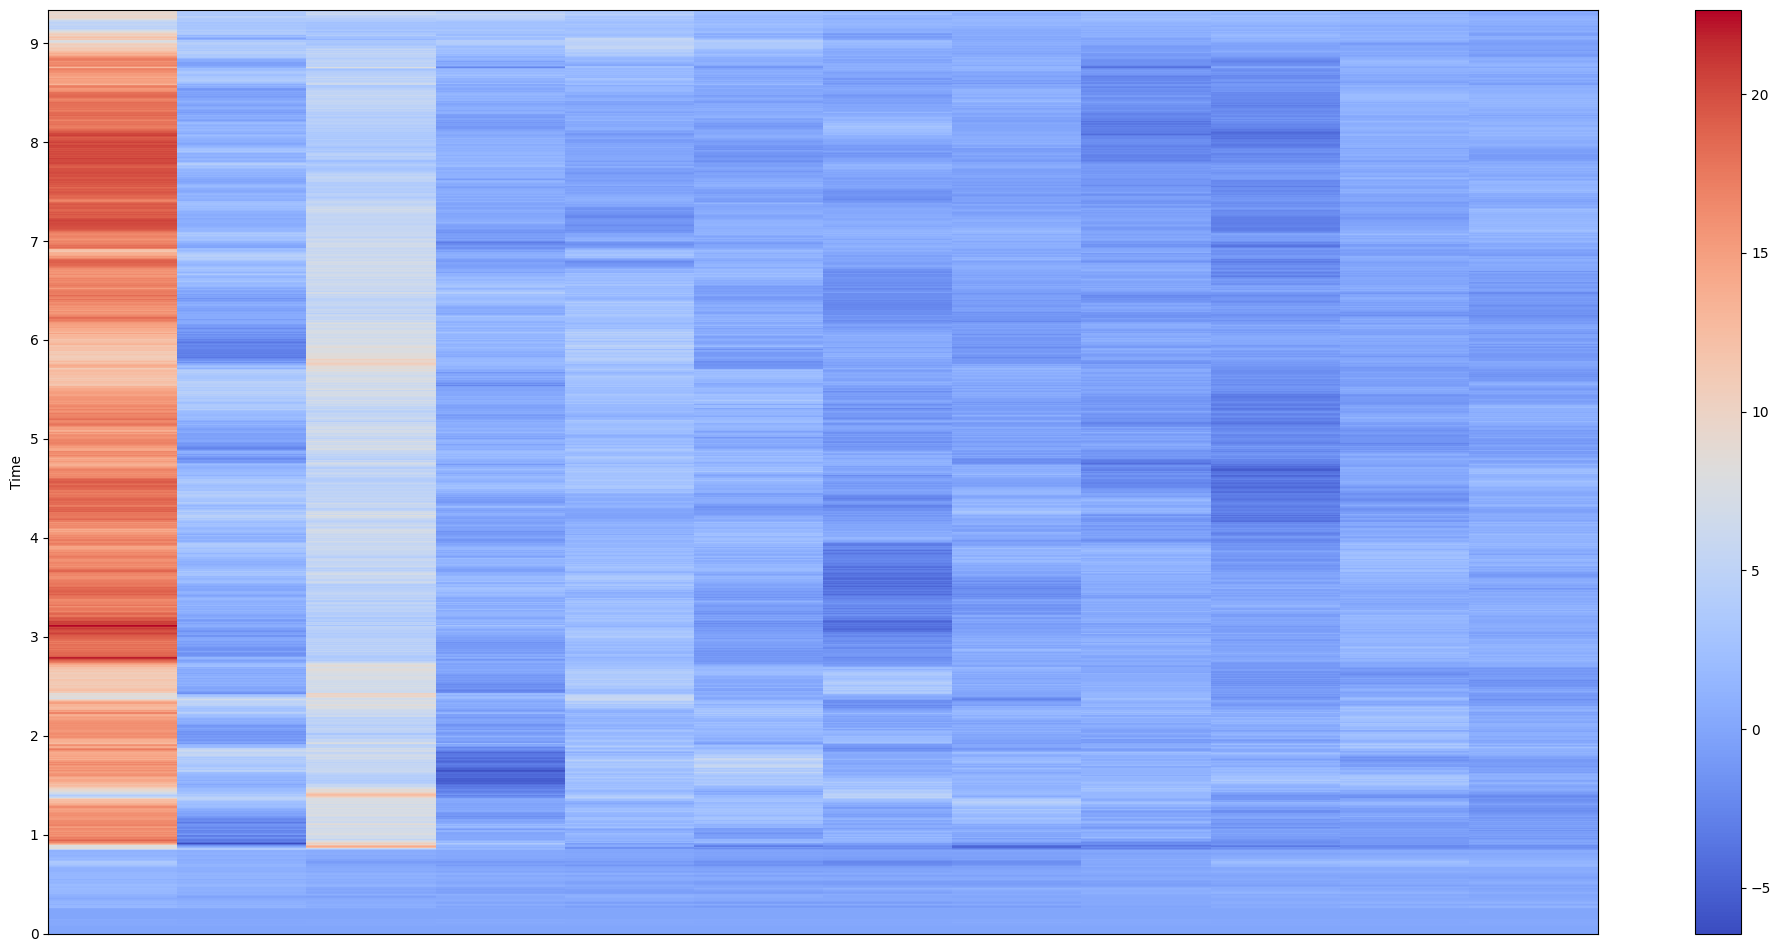

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -7.65370511e-15
  0.00000000e+00 -1.84262807e-15  0.00000000e+00 -1.74496020e-15
  0.00000000e+00 -1.62184688e-15  0.00000000e+00 -1.47508338e-15]


In [ ]:
# DCT pour obtenir les MFCCs

mfcc = dct(
    log_mel_spectrum,
type=2,
    axis=1,
    norm='ortho'
)

mfcc = mfcc[:,1:13]
plt.figure(figsize=(25,12))
librosa.display.specshow(mfcc,
                        sr=Fs,
                        x_axis=None,
                        y_axis="time",
                        hop_length=441)

plt.colorbar()
plt.show()
#Ce son est principalement grave 
print(mfcc[0,:13])